테스트 데이터셋 생성 (ppt 100장 이상)
1. ppt 데이터 추출, 데이터 정제 노드까지만  분리
2. LLM 사용해 정제 데이터 - 정답 도구 - 모범 쿼리 생성

툴 노드 툴 추가
1. tool node에 분리. arxiv, rag, None 추가.
2. tool node prompt 고도화
3. LLM별 테스트 데이터셋으로 실행 도구 - 실행 쿼리 전체 저장.


### 전체 진행
1. ok) 데이터셋 : ppt추출, 데이터 정제 노드 분리
2. ok) 툴 : tool node 분리
- 무한루프 잘 해결되었는지 확인
- 테스트 데이터셋으로 tool node 실행한다음 그 결과가 잘 저장되는지 확인
3. ok) 툴 : tool 추가
4. ok) 툴 : 테스트용 ppt 만들며 tool node prompt 깎기
- 테스트 데이터 만들기
- tavily, arxiv prompt 깎기
- 정제 프롬프트 수정 : 작은 텍스트, 논문 인용구, 표 안의 모든 내용 등을 삭제하지 않도록 지시.

5. ok) 데이터셋 : LLM으로 정답 데이터 생성 (gpt-5)
6. 데이터셋 점검
- labeled 데이터 점검 (rule-based, llm-as-a-judge).
rule based : 형식을 만족하는지
llm-as-a-judge : 올바른 검색 query가 입력되었는지.슬라이드 데이터를 충분히 가지고 있는지.

6. 평가 : 다양한 LLM별 실행
평가 & 시각화

7. 이후 추가
-> 이전 prompt를 적용했을 때와 prompt 고도화 한 다음의 tool call 성능 비교
-> 검색한 주제를 한줄로 정리해 계속 업데이트하며 중복검색 안하도록
-> 노드, workflow 명세서 작성해 추가



# 0. 환경설정

미프 환경설정 그대로 복원

In [1]:
%%bash
set -e

# (1) 필수 패키지
sudo apt-get update -y
sudo apt-get install -y \
  libreoffice poppler-utils poppler-data ffmpeg locales fontconfig xvfb \
  fonts-noto-core fonts-noto-cjk fonts-noto-cjk-extra

# (2) 로케일
sudo sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
sudo locale-gen ko_KR.UTF-8
sudo update-locale LANG=ko_KR.UTF-8

# (3) 기존에 만들었던 사용자 fonts.conf(전체 덮어쓰기) 제거
rm -f ~/.config/fontconfig/fonts.conf || true

# (4) 시스템 fontconfig에 로컬 룰로만 추가 (기본 설정은 그대로 사용)
sudo tee /etc/fonts/local.conf >/dev/null <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

  <!-- 한국어는 Noto Sans KR 우선 -->
  <match target="pattern">
    <test name="lang" compare="contains"><string>ko</string></test>
    <edit name="family" mode="prepend" binding="strong">
      <string>Noto Sans KR</string>
      <string>Noto Sans CJK KR</string>
      <string>Noto Sans</string>
    </edit>
  </match>

  <!-- 흔한 한글 폰트명을 Noto Sans KR로 매핑 -->
  <alias><family>Malgun Gothic</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>맑은 고딕</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>Apple SD Gothic Neo</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>AppleGothic</family><prefer><family>Noto Sans KR</family></prefer></alias>

</fontconfig>
EOF

# (5) 캐시 완전 재생성
rm -rf ~/.cache/fontconfig
sudo fc-cache -r
fc-cache -f -v >/dev/null

# (6) 검증
echo "---- fc-match ko ----"
fc-match "sans-serif:lang=ko"
echo "---- noto candidates ----"
fc-list | grep -i -E "noto.*(sans|cjk).*kr" | head -n 30 || true

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,947 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,020 kB]
Get:14 http://sec

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 150.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


In [2]:
!pip install langchain-openai langchain-community python-pptx pillow gradio langchain-tavily tavily-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
!apt-get install imagemagick
!sed -i 's/<policy domain="path" rights="none" pattern="@\*"/<policy domain="path" rights="read|write" pattern="@\*"/g' /etc/ImageMagick-6/policy.xml

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common imagemagick-6.q16 libdjvulibre-text libdjvulibre21
  libfftw3-double3 libgs9 libgs9-common libidn12 libijs-0.35 libilmbase25
  libjbig2dec0 libjxr-tools libjxr0 liblqr-1-0 libmagickcore-6.q16-6
  libmagickcore-6.q16-6-extra libmagickwand-6.q16-6 libnetpbm10 libopenexr25
  libwmflite-0.2-7 netpbm
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x imagemagick-doc autotrace cups-bsd | lpr | lprng enscript gimp
  gnuplot grads hp2xx html2ps libwmf-bin mplayer povray radiance sane-utils
  texlive-base-bin transfig ufraw-batch libfftw3-bin libfftw3-dev inkscape
The following NEW packages will be installed:
  fonts-droid-fallback fonts-urw-base35 ghostscript gsfonts imagemagick
  imagemagick-6-common imagemagick-

In [4]:
# !sudo apt-get install -y libreoffice
# !sudo apt-get install -y poppler-utils

In [5]:
# !pip install python-pptx langchain-openai langchain-tavily

In [6]:
import os, re, base64, mimetypes, subprocess, tempfile, csv
from pathlib import Path
from typing import List, Dict, Any, Annotated, Optional

from PIL import Image
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode

# from dotenv import load_dotenv
# load_dotenv()

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [7]:
import os, getpass
os.environ["OPENAI_API_KEY"] = ''
os.environ["TAVILY_API_KEY"] = ''
#getpass.getpass("OpenAI API Key 입력: ")
#getpass.getpass("Tavily API Key 입력: ")

In [8]:
print(os.environ['OPENAI_API_KEY'][:30])
print(os.environ['TAVILY_API_KEY'][:30])

sk-proj-ezzUvnzxQaJLy3Vu0cUx4n
tvly-dev-1GsaeV-b04KuH5hfTfyTd


In [9]:
LLM_MODEL = "gpt-5"
llm = ChatOpenAI(model=LLM_MODEL, temperature=0.3)

# 1. 테스트 데이터셋 생성 — PPT 파싱 + 데이터 정제 노드 분리

### 필요 함수

In [10]:
def clean_text(s):
    return re.sub(r"\s+", " ", s).strip()

def img_to_data_url(path: str) -> str:
    mime = mimetypes.guess_type(path)[0] or "image/png"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

def export_slide_as_png(state: dict, dpi: int = 220) -> dict:
    # 1. 기본 설정 : 작업 디렉토리 만들기, PPT 불러오기, 슬라이드 번호 계산
    work_dir = Path(state["work_dir"]).expanduser().resolve()
    work_dir.mkdir(parents=True, exist_ok=True)

    pptx = Path(state["pptx_path"]).expanduser().resolve()
    if not pptx.exists():
        raise FileNotFoundError(f"PPTX 없음: {pptx}")

    idx = int(state.get("slide_index", 0))
    page_no = idx + 1
    out_prefix = work_dir / "slide_img"

    lo_profile_dir = Path(tempfile.mkdtemp(prefix="lo_profile_"))
    lo_profile = lo_profile_dir.as_uri()

    # print('1. 기본 설정')
    # print(f'work_dir : {work_dir}')
    # print(f'pptx : {pptx}')
    # print(f'idx : {idx}, page_no : {page_no}')

    # 2. Libreoffice PPT -> PNG 변환
    # print("2. Libreoffice PPT -> PNG 변환")
    def run_lo_convert(convert_to: str):
        cmd = [
            "soffice", "--headless", "--nologo", "--nofirststartwizard", "--norestore",
            f"-env:UserInstallation={lo_profile}",
            "--convert-to", convert_to,
            "--outdir", str(work_dir),
            str(pptx),
        ]
        return subprocess.run(cmd, capture_output=True, text=True)

    # 2-1. 변환 확인
    # png변환 후 새로운 png가 있는지 감지
    before_png = set(work_dir.glob("*.png"))
    run_lo_convert("png:impress_png_Export")
    created_png = [p for p in work_dir.glob("*.png") if p not in before_png]

    # print(f'created_png : {created_png}')

    # 새로운 png에 현재 만들고 있는 page_no에 맞는 png가 있는지
    candidate = None
    exact = [p for p in created_png if p.stem.endswith(f"-{page_no}")]
    if exact:
        candidate = max(exact, key=lambda p: p.stat().st_mtime)
    elif created_png:
        candidate = max(created_png, key=lambda p: p.stat().st_mtime)

    if candidate and candidate.exists():
        state["slide_image"] = str(candidate)
        return state

    # 3. Libreoffice PPT -> PDF 변환
    # 2번이 실패했을 때 PDF로 변환한 후 PNG로 추출
    # print('3. Libreoffice PPT -> PDF 변환')
    before_pdf = set(work_dir.glob("*.pdf"))
    res_pdf = run_lo_convert("pdf:impress_pdf_Export")
    target_pdf = work_dir / f"{pptx.stem}.pdf"
    created_pdf = [p for p in work_dir.glob("*.pdf") if p not in before_pdf]

    if target_pdf.exists():
        pdf_path = target_pdf
    elif created_pdf:
        pdf_path = max(created_pdf, key=lambda p: p.stat().st_mtime)
    else:
        raise RuntimeError("PPTX → PDF 변환 실패")

    # print(f'created_pdf : {created_pdf}')

    # 3-1. pdftoppm PDF -> PNG 변환
    ppm_cmd = [
        "pdftoppm", "-f", str(page_no), "-l", str(page_no),
        "-png", "-r", str(dpi), str(pdf_path), str(out_prefix)
    ]
    subprocess.run(ppm_cmd, capture_output=True, text=True)

    # 3-2. 최종 PNG 파일 확인 후 변환
    # pdftoppm 버전에 따라, 슬라이드 전체 길이에 따라 page_no 표현방식이 달라 수동으로 업데이트 해주어야함.
    #->10장이상 :02d 10장이하 :d
    png_path = Path(f"{out_prefix}-{page_no:06d}.png")
    if not png_path.exists():
        png_path = Path(f"{out_prefix}-{page_no:02d}.png")
    if not png_path.exists():
        png_path = Path(f"{out_prefix}-{page_no}.png")
    if not png_path.exists():
        raise RuntimeError("PDF → PNG 변환 실패")

    state["slide_image"] = str(png_path)
    return state

### LangGraph

In [11]:
# State 정의 (파싱 + 정제 단계에 필요한 필드만)

class State(TypedDict, total=False):
    pptx_path: str
    work_dir: str

    slides: List[Dict[str, Any]]   # [{index, title, texts, tables, images, snap, content}]
    n_slides: int
    slide_index: int

    cur_page_content: str
    messages: Annotated[list, add_messages]

In [12]:
# 노드 1 : PPT 전체 파싱

def node_parse_all(state: State) -> State:
    print("1. PPT 전체 파싱")

    pres = Presentation(state["pptx_path"])
    work_dir = state["work_dir"]
    media_dir = os.path.join(work_dir, "media")
    os.makedirs(media_dir, exist_ok=True)

    slides_out = []

    for idx, slide in enumerate(pres.slides, start=1):
        title_shape = slide.shapes.title
        title = title_shape.text if title_shape else "제목 없음"

        texts, tables, images = [], [], []

        for i, sh in enumerate(slide.shapes):
            if sh.has_text_frame:
                txt = "\n".join(p.text for p in sh.text_frame.paragraphs)
                texts.append(txt)
            if sh.shape_type == MSO_SHAPE_TYPE.TABLE:
                tbl = [[clean_text(c.text) for c in r.cells] for r in sh.table.rows]
                tables.append(tbl)
            if sh.shape_type == MSO_SHAPE_TYPE.PICTURE:
                ext = sh.image.ext
                path = os.path.join(media_dir, f"slide{idx}_{i}.{ext}")
                images.append(path)
                try:
                    with open(path, "wb") as f:
                        f.write(sh.image.blob)
                except Exception as e:
                    print(f"이미지 저장 오류: {e}")

        tmp_state = {"pptx_path": state["pptx_path"], "work_dir": work_dir, "slide_index": idx - 1}
        print(f'tmp_state : {tmp_state}')
        snap_state = export_slide_as_png(tmp_state)
        snap = snap_state["slide_image"]

        slides_out.append({
            "index": idx,
            "title": title,
            "texts": texts,
            "tables": tables,
            "images": images,
            "snap": snap,
            "content": ""
        })
        print(f"  슬라이드 {idx}/{len(pres.slides)} 파싱 완료")

    state["slides"] = slides_out
    state["n_slides"] = len(slides_out)
    state["slide_index"] = 0
    state["cur_page_content"] = ""
    state["messages"] = []

    return state

In [13]:
# 노드 2 : 슬라이드 데이터 정제 (LLM)

def node_generate_text(state: State) -> State:
    cur_index = state["slide_index"]
    slide = state["slides"][cur_index]
    print(f"2. 데이터 정제 — 슬라이드 {cur_index + 1}/{state['n_slides']}")

    title = slide.get("title", "")
    texts = slide.get("texts", [])
    tables = slide.get("tables", [])
    images = list(slide.get("images", []) or [])

    table_snip = ""
    if tables:
        try:
            table_snip = "\n".join([" | ".join(map(str, r)) for r in tables[0][:6]])
        except Exception:
            table_snip = str(tables[0][:6])

    snap = slide.get("snap")
    if snap and snap not in images:
        images.insert(0, snap)

    sys_msg = """
    # 역할
    당신은 PPT 내용 정리 전문가입니다.
    아래는 PPT로부터 추출한 전체 객체들입니다. 입력된 객체 내용을 사용해 전체 내용을 작성해주세요.

    # 규칙
    1. 모든 내용을 단 하나도 빠트리지 말고 전부 사용할 것.
    2. 왜곡, 과장하거나 상상해서 적지 말 것.
    3. 있는 그대로 모든 것을 작성할 것.
    4. 고유명사를 임의로 다른 단어로 변경해 작성하지 말 것.
    5. ppt 내용 외의 출력은 제한할 것.
    6. 입력된 이미지를 충분히 설명할 것.
    """

    user_text = "\n\n".join([
        f"[제목]\n{title if title else '[제목 없음]'}",
        f"[텍스트]\n{texts if texts else '[없음]'}",
        f"[표]\n{table_snip if table_snip else '[없음]'}"
    ])
    human_msg = [{"type": "text", "text": user_text}]

    for image in images:
        try:
            data_url = img_to_data_url(image)
            human_msg.append({"type": "image_url", "image_url": {"url": data_url}})
        except Exception:
            pass

    result = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    state["cur_page_content"] = result.content
    state["slides"][cur_index]["content"] = result.content

    return state

In [14]:
# 루프 제어 노드 & 분기 함수

def acc_step(state: State) -> State:
    state["slide_index"] = state["slide_index"] + 1
    return state

def acc_step_func(state: State):
    if state["slide_index"] < state["n_slides"]:
        return "CONTINUE"
    return "END"

In [15]:
builder = StateGraph(State)

builder.add_node("parse_all", node_parse_all)
builder.add_node("gen_page", node_generate_text)
builder.add_node("acc_step", acc_step)

builder.add_edge(START, "parse_all")
builder.add_edge("parse_all", "gen_page")
builder.add_edge("gen_page", "acc_step")
builder.add_conditional_edges("acc_step", acc_step_func,
                              {"CONTINUE": "gen_page", "END": END})

dataset_graph = builder.compile()

### 실행 & csv 저장

In [ ]:
import os
import csv

def extract_slides_to_csv(pptx_path: str, csv_path: str, work_dir: str = "./"):
    """
    PPT 파일을 읽어 슬라이드 정보를 CSV로 저장하는 함수

    Args:
        pptx_path: PPT 파일 경로
        csv_path:  저장할 CSV 파일 경로
        work_dir:  작업 디렉토리 (기본값: 현재 디렉토리)
    """
    os.makedirs(work_dir, exist_ok=True)

    result = dataset_graph.invoke({
        "pptx_path": pptx_path,
        "work_dir":  work_dir,
    })

    fieldnames = ["slide_index", "title", "content", "answer_tool", "answer_query"]

    with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for slide in result["slides"]:
            writer.writerow({
                "slide_index":  slide["index"],
                "title":        slide["title"],
                "content":      slide["content"],
                "answer_tool":  "",
                "answer_query": "",
            })

    print(f"CSV 저장 완료: {csv_path}  ({len(result['slides'])}행)")
    return result

In [ ]:
# extract_slides_to_csv(pptx_path="./None예시.pptx",
#     csv_path="./test_dataset_None.csv",
#     work_dir = "./None예시"
# )

# extract_slides_to_csv(pptx_path="./tavily예시1.pptx",
#     csv_path="./test_dataset_tavily1.csv",
#     work_dir = "./tavily예시1"
# )
# extract_slides_to_csv(pptx_path="./tavily예시2.pptx",
#     csv_path="./test_dataset_tavily2.csv",
#     work_dir = "./tavily예시2"
# )
# extract_slides_to_csv(pptx_path="./tavily예시3.pptx",
#     csv_path="./test_dataset_tavily3.csv",
#     work_dir = "./tavily예시3"
# )

extract_slides_to_csv(pptx_path="./arxiv예시2.pptx",
    csv_path="./test_dataset_arxiv2.csv",
    work_dir = "./arxiv예시2"
)
extract_slides_to_csv(pptx_path="./arxiv예시3.pptx",
    csv_path="./test_dataset_arxiv3.csv",
    work_dir = "./arxiv예시3"
)

1. PPT 전체 파싱
tmp_state : {'pptx_path': './arxiv예시2.pptx', 'work_dir': './arxiv예시2', 'slide_index': 0}
  슬라이드 1/15 파싱 완료
tmp_state : {'pptx_path': './arxiv예시2.pptx', 'work_dir': './arxiv예시2', 'slide_index': 1}
  슬라이드 2/15 파싱 완료
tmp_state : {'pptx_path': './arxiv예시2.pptx', 'work_dir': './arxiv예시2', 'slide_index': 2}
  슬라이드 3/15 파싱 완료
tmp_state : {'pptx_path': './arxiv예시2.pptx', 'work_dir': './arxiv예시2', 'slide_index': 3}
  슬라이드 4/15 파싱 완료
tmp_state : {'pptx_path': './arxiv예시2.pptx', 'work_dir': './arxiv예시2', 'slide_index': 4}
  슬라이드 5/15 파싱 완료
tmp_state : {'pptx_path': './arxiv예시2.pptx', 'work_dir': './arxiv예시2', 'slide_index': 5}
  슬라이드 6/15 파싱 완료
tmp_state : {'pptx_path': './arxiv예시2.pptx', 'work_dir': './arxiv예시2', 'slide_index': 6}
  슬라이드 7/15 파싱 완료
tmp_state : {'pptx_path': './arxiv예시2.pptx', 'work_dir': './arxiv예시2', 'slide_index': 7}
  슬라이드 8/15 파싱 완료
tmp_state : {'pptx_path': './arxiv예시2.pptx', 'work_dir': './arxiv예시2', 'slide_index': 8}
  슬라이드 9/15 파싱 완료
tmp_state : {'pptx_path'

{'pptx_path': './arxiv예시3.pptx',
 'work_dir': './arxiv예시3',
 'slides': [{'index': 1,
   'title': '제목 없음',
   'texts': ['Knowledge Intelligence Lab. Hanbat National University',
    '',
    'Advanced RAG\nRAPTOR\n의미가 유사한 chunk 별로\nclustering -> 추상 요약\n관련 정보를 포함하고 있는\nchunk 별로 새로운 chunk 생성\n유의미한 multi-hop 생성\n\nDocument clustering\nGaussian Mixture Models\n100 token chunking',
    'Retrievals – Embeddings and ranking – RAG',
    'RAPTOR: Recursive Abstractive Processing for Tree-Organized Retrieval, ICLR24’',
    '1'],
   'tables': [],
   'images': ['./arxiv예시3/media/slide1_5.jpg',
    './arxiv예시3/media/slide1_6.jpg'],
   'snap': '/content/arxiv예시3/arxiv예시3.png',
   'content': '- 제목: 제목 없음\n- 상단 표기: Knowledge Intelligence Lab. Hanbat National University\n- 섹션: Retrievals – Embeddings and ranking – RAG\n- 슬라이드 제목: Advanced RAG\n  - RAPTOR\n  - 의미가 유사한 chunk 별로\n    - clustering -> 추상 요약\n  - 관련 정보를 포함하고 있는\n    - chunk 별로 새로운 chunk 생성\n    - 유의미한 multi-hop 생성\n  - Document clustering\n   

In [ ]:
import pandas as pd
CSV_PATH = './test_dataset_arxiv1.csv'
df_test = pd.read_csv(CSV_PATH)
display(df_test)

,slide_index,title,content,answer_tool,answer_query
0,1,차별성 1 – 독보적인 성능,오픈소스컨설팅 LLM의 차별성\n\n차별성 1 – 독보적인 성능\n- 글로벌 최고 ...,NaN,NaN
1,2,제목 없음,제목 없음\n\n차별성 2 – 획기적인 가격 경쟁력\n- 양자화 기술과 Servin...,NaN,NaN
2,3,Generative AI: Your Mileage May Vary,Generative AI: Your Mileage May Vary\nState of...,NaN,NaN
3,4,State of the Art (2/2)\nGenerative AI: Know Yo...,- Title: State of the Art (2/2)\n- Subtitle: G...,NaN,NaN
4,5,제목 없음,제목 없음\n\n- Knowledge Intelligence Lab. Hanbat ...,NaN,NaN
5,6,제목 없음,Knowledge Intelligence Lab. Hanbat National Un...,NaN,NaN
6,7,제목 없음,제목 없음\n\nKnowledge Intelligence Lab. Hanbat Na...,NaN,NaN
7,8,제목 없음,- 제목 없음\n- Knowledge Intelligence Lab. Hanbat ...,NaN,NaN
8,9,제목 없음,- Knowledge Intelligence Lab. Hanbat National ...,NaN,NaN
9,10,제목 없음,제목 없음\n\n- Knowledge Intelligence Lab. Hanbat ...,NaN,NaN


In [ ]:
for i in range(0, len(df_test)):
  print(df_test['content'].loc[i])
  print('================================================================================================================================================================')

오픈소스컨설팅 LLM의 차별성

차별성 1 – 독보적인 성능
- 글로벌 최고 수준의 ChatGPT 사용을 무리 없이 대체할 수 있을 만큼 탁월한 성능과 차별적인 기능을 보유하고 있습니다.
- 1. CoIT 학습 방식을 적용하여 한국어로도 최상급 성능 보유
  오픈소스가 기존에 보유한 영어에 대한 최상급 언어 능력을 한국어로 치환하는 CoIT 학습 방식을 적용하여 한국어 능력이 떨어지던 기존 LLM의 고질적인 문제를 해결하였습니다.
  특히 최근 Vocab 확장을 통해 한국어 생성 속도 및 context length가 약 1.3배 증가하는 등 한국어 성능을 점차 고도화하고 있습니다.
- 2. Catastrophic Forgetting 문제 해결
  단계별 학습 진행 등 Catastrophic Forgetting*을 완화하기 위한 학습법을 끊임없이 연구하여 높은 모델 안정성을 확보하고 있습니다.
  * Catastrophic Forgetting: 새로운 데이터를 학습하며 이전 학습 정보를 잃는 현상
- 3. 자체 필터링 시스템을 통한 고품질 학습 데이터 보유
  자체 필터링 시스템을 기반으로 학습 데이터의 품질을 관리하고 있으며, 사람이 검수하여 정교함이 높은 고품질의 SFT 데이터를 보유하고 있습니다.

[MAAL의 뛰어난 한국어 성능]
LLM ‘MAAL’은 모델 별 한국어 문장 이해 능력 향상 평가(KoBEST)를 통해 한국어 성능을 입증했으며,, ‘MAAL-albatross 70B’을 LogicKor 프롬프트 및 gpt-4-turbo로 채점한 결과, ChatGPT 못지 않은 점수를 기록했습니다.

[테스트 전체 평균]
- MAAL 70B: 9.06
- GPT-4o: 9.59
- Gemini-1.0-pro: 8.31

[자체 필터링 시스템 예시]
- 평균 perplexity value 비교:
  perp['perplexity'].mean(), filtered_df['perplexity'].mean()
  (1642.321295874146, 1221.836041

In [ ]:
from google.colab import files

# files.download('./test_dataset_arxiv1.csv')
# files.download('./test_dataset_arxiv2.csv')
files.download('./test_dataset_arxiv3.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
a1 = pd.read_csv('test_dataset_arxiv1.csv')
a2 = pd.read_csv('test_dataset_arxiv2.csv')
a3 = pd.read_csv('test_dataset_arxiv3.csv')
a_concat = pd.concat([a1,a2,a3]).reset_index(drop=True)
a_concat['slide_index'] = [i for i in range(1, len(a_concat) + 1)]
a_concat.to_csv('test_dataset_arxiv.csv', index=False, encoding = 'utf-8-sig')

# 2. Tool Node

### LangGraph

In [27]:
!pip install langchain-community wikipedia arxiv==1.4.8 -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.7 MB/s eta 0:00:00


In [65]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain.tools import tool
import arxiv

tavily_tool = TavilySearch(max_results=3)
                          # description = "최신 뉴스, 실무 적용 사례, 구현 예시, 현장 트러블슈팅을 찾을 때 사용")

@tool
def arxiv_tool(query: str) -> str:
    """학술 논문, 연구 결과, 알고리즘의 이론적 근거를 찾을 때 사용"""
    client = arxiv.Client()
    search = arxiv.Search(query=query, max_results=1)

    results = []
    for paper in client.results(search):
        results.append(
            f"제목: {paper.title}\n"
            f"연도: {paper.published.year}\n"
            f"요약: {paper.summary}\n"
            f"URL: {paper.entry_id}"
        )
    result_text = "\n\n".join(results) if results else "결과 없음"
    print('paper_info : ', result_text)
    return result_text

wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=2000),)
                            #  description = "기술 용어 정의, 개념 배경지식, 역사적 맥락을 찾을 때 사용")

tool_list = [tavily_tool, arxiv_tool, wiki_tool]
tool_node = ToolNode(tool_list, handle_tool_errors=True)

tool_llm = ChatOpenAI(model='gpt-5.5', temperature=0.3)
llm_with_tools = tool_llm.bind_tools(tool_list)

In [66]:
class ToolState(TypedDict, total=False):
    cur_page_content: str
    cur_search_context: str
    messages: Annotated[list, add_messages]

In [74]:
# 전체 프롬프트
def tool_search(state: ToolState) -> dict:
    sys_msg = """
    #역할
    당신은 검색 전문가입니다. 입력은 현재 PPT 슬라이드의 전체 내용을 빠짐없이 적은 것입니다.
    이를 읽고 도구 선택 기준에 맞으면 도구를 사용해 검색해주세요.
    사용할 수 있는 도구는 다음과 같습니다. : tavily_search, arxiv_search
    구체적인 내용 없이 전체 내용이 짧은 경우 표지, 목차, 섹션 구분 등에 해당합니다.

    # 도구 선택 기준
    1. tavily_search : 특정 서비스와 제품에 대한 정보가 필요할 때
    특정 제품/서비스가 명시되어 있고 그에 대한 구체적인 정보(기능, 성능, 비교 등) 내용을 담은 슬라이드일 때 해당 제품에 대한 최신 정보와 동향을 검색.

    - tavily 쿼리 지침
    쿼리는 핵심 키워드만 사용해 간결하게 작성하세요.
    슬라이드에 나와 있는 핵심 제품 한 가지에 대해서만 검색하세요.
    검색어는 3~5단어면 충분합니다.

    검색 필요 예시)
    MAAL (Multilingual Adaptive Augmentation Language-model) 한국어에 강한 언어 생성 모델 MAAL을 기반으로 On-premise LLM 솔루션을 제공합니다. 다양한 파라미터 수의 모델(8B-70B)을 기반으로 고객의 니즈에 맞는 모델을 지원합니다... On-premise용으로는 성능이 뛰어나며 범용적으로 사용하기 좋은 MAAL-albatross(70B)를 권장하고 있습니다. -> MAAL 관련 검색
    Agados UI, Flow Design & Visibility Technologies Structure of this presentation Application을 위한 Architecture - SW Package를 위한 Smart Architecture - Hybrid Architecture Overview - 타 시스템과의 Interface... -> Agados 관련 검색

    2. arxiv_search : 연구에 대한 구체적인 성능 내용이 필요할 때
    연구, 성능 그래프, 성능 표, 논문 인용 표기 등이 명시되어 있을 때 그와 관련한 논문 검색.

    - arxiv 쿼리 지침
    슬라이드에 나와 있는 핵심적인 것 단 한가지에 대해서만 검색하세요.

    검색 필요 예시)
    - "REPLUG: Retrieval-Augmented Black-Box Language Models, NAACL24'", "Dense Passage Retrieval for Open-Domain Question Answering, EMNLP20'" -> 논문 검색
    - 마크다운 형식으로 전환된 그래프의 성능, 메트릭 표 -> 논문 검색
    - 특정 모델의 벤치마크 점수가 수치로 제시된 경우 예) "MAAL 70B: 9.06 / GPT-4o: 9.59" 처럼 모델별 점수 비교표가 포함된 슬라이드 -> 논문 검색
    - LogicKor, KoBEST, MMLU 등 평가 지표명이 명시된 경우

    3. 검색이 필요 없는 경우
    그 외 아래의 경우에 해당할 경우 '검색 필요 없음'과 그 이유를 출력하세요
    - 형식적 내용 : 표지, 개요, 목차, 섹션 구분, 마지막 페이지(Q&A, 감사합니다) 등의 슬라이드로 판단되는 경우
    - 소개 : 학습 목표, 강사 소개, 참고문헌 목록, 레퍼런스 목록 등을 소개하는 내용인 경우.
    - 그 외 어떠한 도구 선택 기준의 경우에도 해당하지 않는 경우.

    검색 불필요 예시)
    - 제목: 제목 없음\n- Chapter 2. 오픈소스 컨설팅의 On-premise LLM 솔루션\n- MAAL (Multilingual Adaptive Augmentation Language-model) MAAL 기반 On-premise 패키지\n  - 챗봇\n  - Chatplay\n  - LLM Task UI\n- 표: 없음 -> 목차 슬라이드
    Biz. Application을 위한 디자이너/재조정기\n‘아가도스’는 귀사의 SW Application내에서 Configure Tool의 역할 수행\n19\nⒸ 2014 agados All rights reserved. -> 섹션 구분
    제목: Jamcracker 소개 시작\n\nCloud Management Platform & Cloud Service Brokerage\n\n- CLOUD SERVICES BROKERAGE\n- CLOUD GOVERNANCE\n- MICROSOFT CSP ENABLEMENT\n- HYBRID CLOUD MANAGEMENT\n- Microsoft Cloud Solution Provider\n- OSC ASIA GROUP LIMITED\n- @ OSC Korea & OSC Asia Group jerry@osckorea.com jerry@oscasia.net +82 10 9196 1416 -> 목차 슬라이드

    # 규칙
    - 검색 시 하나의 도구만 사용하세요.
    - 대화 로그를 보았을 때 이미 검색을 진행했다면 추가 검색을 하지 말고 검색 결과를 전체 정리해주세요.
    - 검색 결과 정리시 핵심 내용을 정리해 작성해주세요.
    - 검색 결과 요약 시 검색 결과를 제외한 다른 어떠한 출력도 하지 마세요.
"""

    human_msg = "[슬라이드 내용]\n" + state.get("cur_page_content", "") + "\n[대화 로그]"+ "\n\n".join([message.content for message in state['messages']])
    result = llm_with_tools.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    return {"cur_search_context": result.content, "messages": [result]}


def is_tool_needed(state: ToolState):
    if state["messages"][-1].tool_calls:
        return "tool_call"
    return "no_tool_call"


In [143]:
#arxiv labeled 데이터 생성용 prompt
import time
def tool_search(state: ToolState) -> dict:
    sys_msg = """
    #역할
    당신은 검색 전문가입니다. 입력은 현재 PPT 슬라이드의 전체 내용을 빠짐없이 적은 것입니다.
    현재 PPT는 연구, 성능 그래프, 성능 표, 논문 인용 표기 등에 대한 구체적인 내용이 명시되어 있습니다.
    arxiv 도구를 사용해 검색해주세요.

    #도구
    arxiv_search : 연구, 성능 그래프, 성능 표, 논문 인용 표기 등과 관련한 논문 검색.

    #쿼리 지침
    슬라이드에 나와 있는 핵심적인 것 단 한가지에 대해서만 검색하세요.

    검색 필요 예시)
    - "REPLUG: Retrieval-Augmented Black-Box Language Models, NAACL24'", "Dense Passage Retrieval for Open-Domain Question Answering, EMNLP20'" -> 논문 검색
    - 마크다운 형식으로 전환된 그래프의 성능, 메트릭 표 -> 논문 검색
    - 특정 모델의 벤치마크 점수가 수치로 제시된 경우 예) "MAAL 70B: 9.06 / GPT-4o: 9.59" 처럼 모델별 점수 비교표가 포함된 슬라이드 -> 논문 검색
    - LogicKor, KoBEST, MMLU 등 평가 지표명이 명시된 경우

    # 규칙
    - 대화 로그를 보았을 때 이미 검색을 진행했다면 추가 검색을 하지 말고 검색 결과를 전체 정리해주세요.
    - 검색 결과 정리시 핵심 내용을 정리해 작성해주세요.
    - 검색 결과 요약 시 검색 결과를 제외한 다른 어떠한 출력도 하지 마세요.
"""

    human_msg = "[슬라이드 내용]\n" + state.get("cur_page_content", "") + "\n[대화 로그]"+ "\n\n".join([message.content for message in state['messages']])
    result = llm_with_tools.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])
    # result = llm_with_tools.invoke(
    # [SystemMessage(content=sys_msg)]
    # + state['messages']
    # + [HumanMessage(content="[슬라이드 내용]\n" + state.get("cur_page_content", ""))]
    #  )
    print("============================tool search human msg=============================")
    print(human_msg)

    print('===========================================================================')
    time.sleep(1.5)
    return {"cur_search_context": result.content, "messages": [result]}


def is_tool_needed(state: ToolState):
    if state["messages"][-1].tool_calls:
        return "tool_call"
    return "no_tool_call"


In [144]:
# 그래프 빌드
tool_builder = StateGraph(ToolState)
tool_builder.add_node("tool_search", tool_search)
tool_builder.add_node("tool_node", tool_node)

tool_builder.add_edge(START, "tool_search")
tool_builder.add_conditional_edges("tool_search", is_tool_needed,
                                   {"tool_call": "tool_node", "no_tool_call": END})
tool_builder.add_edge("tool_node", "tool_search")

tool_graph = tool_builder.compile()
print("Tool 그래프 빌드 완료")

Tool 그래프 빌드 완료


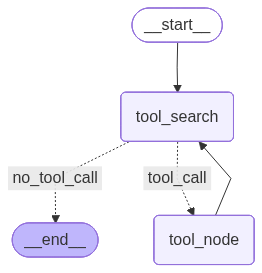

In [145]:
tool_graph

### 짧은 테스트

In [115]:
import pandas as pd
df_test = pd.read_csv('test_dataset_arxiv.csv')

In [100]:
test_content = df_test['content'].loc[47]
print(test_content)

for chunk in tool_graph.stream({'cur_page_content': test_content, 'messages': []},stream_mode="updates"):
    node_name = list(chunk.keys())[0]
    state = chunk[node_name]

    print(f"\n{'='*40}")
    print(f"📍 Node: {node_name}")
    print(f"{'='*40}")
    print(state)

제목 없음

Context Window Size
Input Size

마이크로소프트(MS)가 롱넷(LongNet) 트랜스포머 모델을 도입하여 10억 토큰의 컨텍스트를 0.5초에 처리하고 기하급수적인 비용 증가를 선형으로 개선함. 토큰 수가 증가하면 비용이 증가하며, 롱넷을 통해 저렴한 비용으로 해리포터 1000권을 0.5초에 처리할 수 있게 되었다. 큰 컨텍스트 창은 LLM 성능 향상과 학습 기능 강화에 기여하며, 컨텍스트 내 학습이 더 나은 답변을 가능하게 함.

출처 : https://www.aitimes.com/news/articleView.html?idxno=152588

ChatGPT Prompt Learning Research LAB Leader TAE YOUNG LEE

표: 없음

📍 Node: tool_search
{'cur_search_context': '', 'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 1901, 'total_tokens': 1961, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 21, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.5-2026-04-23', 'system_fingerprint': None, 'id': 'chatcmpl-DixoLxtkI9M2mi8jCBMmsaxCuWjMB', 'service_tier': 'default', 'finish_

In [ ]:
test_content = df_test['content'].loc[0] #19 20 21

print(test_content)
print('\n\n====================================================================\n\n')

for chunk in tool_graph.stream(
    {'cur_page_content': test_content, 'messages': []},
    stream_mode="updates"  # 각 노드 실행 후 변경된 state만 출력
):
    print(chunk)


- 제목: PXF External Table 예제
- Simple HDFS Text
- CREATE EXTERNAL TABLE jan_2012_sales (
id int, total int,
comments varchar
)
LOCATION(‘pxf://10.76.72.26:50070/sales/ 2012/01/items_*.csv?
profile=HdfsTextSimple
)
FORMAT ‘TEXT’ (delimiter ‘,’);
- Hbase Table
- CREATE EXTERNAL TABLE hbase_sales (
recordkey bytea, “cf1:saleid” int, “cf8:comments” varchar
)
LOCATION(‘pxf://10.76.72.26:50070/sales?
profile=HBase
) FORMAT
‘custom’ (formatter='gpxfwritable_import');
- Export to HDFS using Writable PXF
- CREATE WRITABLE EXTERNAL TABLE ...
LOCATION(‘pxf://<host:port>/sales? profile=HdfsTextSimple&COMPRESSION_CODEC=org.apache.hadoop.io.compress.GzipCodec') FORMAT ‘text’(delimiter ‘,’);
- © 2015 Pivotal Software, Inc. All rights reserved.
- 1
- 표: 없음
{'tool_search': {'cur_search_context': '', 'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 2402, 'total_tokens': 2542, 'completion_tokens_details': 

### 실행 & csv 저장

In [146]:
# 테스트 데이터셋 읽어서 tool_graph 실행 후 결과 저장

from langchain_core.messages import ToolMessage

CSV_INPUT  = "./test_dataset_arxiv.csv"
CSV_OUTPUT = "./test_dataset_arxiv_labeled.csv"

fieldnames = ["slide_index", "title", "content", "tool_called", "tool_name", "query", "raw_tool_result", "tool_node_result"]

with open(CSV_INPUT, "r", encoding="utf-8-sig") as test_dataset, \
     open(CSV_OUTPUT, "w", newline="", encoding="utf-8-sig") as result_data:

    reader = csv.DictReader(test_dataset)
    writer = csv.DictWriter(result_data, fieldnames=fieldnames)
    writer.writeheader()

    for row in reader:
        slide_index = row["slide_index"]
        title       = row["title"]
        content     = row["content"]

        print(f"슬라이드 {slide_index} 처리 중...")

        result = tool_graph.invoke({
            "cur_page_content": content,
            "messages": []
        })

        tool_called       = False
        tool_name         = "none"
        query             = ""
        raw_tool_result = ""

        for msg in result.get("messages", []):
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                tool_called = True
                tool_name   = msg.tool_calls[0].get("name", "unknown")
                query       = msg.tool_calls[0].get("args", {}).get("query", "")
            if isinstance(msg, ToolMessage):
                raw_tool_result = msg.content

        tool_node_result = result.get("cur_search_context", "")

        writer.writerow({
            "slide_index":        slide_index,
            "title":              title,
            "content":            content,
            "tool_called":        tool_called,
            "tool_name":          tool_name,
            "query":              query,
            "raw_tool_result":    raw_tool_result,
            "tool_node_result":   tool_node_result,
        })
        print(f"  → tool_called={tool_called}, tool={tool_name}, query={query[:50] if query else '-'}")

print(f"\n완료: {CSV_OUTPUT}")

import pandas as pd
df_result = pd.read_csv(CSV_OUTPUT)
display(df_result)

슬라이드 1 처리 중...
============================tool search human msg=============================
[슬라이드 내용]
오픈소스컨설팅 LLM의 차별성

차별성 1 – 독보적인 성능
- 글로벌 최고 수준의 ChatGPT 사용을 무리 없이 대체할 수 있을 만큼 탁월한 성능과 차별적인 기능을 보유하고 있습니다.
- 1. CoIT 학습 방식을 적용하여 한국어로도 최상급 성능 보유
  오픈소스가 기존에 보유한 영어에 대한 최상급 언어 능력을 한국어로 치환하는 CoIT 학습 방식을 적용하여 한국어 능력이 떨어지던 기존 LLM의 고질적인 문제를 해결하였습니다.
  특히 최근 Vocab 확장을 통해 한국어 생성 속도 및 context length가 약 1.3배 증가하는 등 한국어 성능을 점차 고도화하고 있습니다.
- 2. Catastrophic Forgetting 문제 해결
  단계별 학습 진행 등 Catastrophic Forgetting*을 완화하기 위한 학습법을 끊임없이 연구하여 높은 모델 안정성을 확보하고 있습니다.
  * Catastrophic Forgetting: 새로운 데이터를 학습하며 이전 학습 정보를 잃는 현상
- 3. 자체 필터링 시스템을 통한 고품질 학습 데이터 보유
  자체 필터링 시스템을 기반으로 학습 데이터의 품질을 관리하고 있으며, 사람이 검수하여 정교함이 높은 고품질의 SFT 데이터를 보유하고 있습니다.

[MAAL의 뛰어난 한국어 성능]
LLM ‘MAAL’은 모델 별 한국어 문장 이해 능력 향상 평가(KoBEST)를 통해 한국어 성능을 입증했으며,, ‘MAAL-albatross 70B’을 LogicKor 프롬프트 및 gpt-4-turbo로 채점한 결과, ChatGPT 못지 않은 점수를 기록했습니다.

[테스트 전체 평균]
- MAAL 70B: 9.06
- GPT-4o: 9.59
- Gemini-1.0-pro: 8.31

[자체 필터링 시스템 예시]
- 평균 perplexity v

,slide_index,title,content,tool_called,tool_name,query,raw_tool_result,tool_node_result
0,1,차별성 1 – 독보적인 성능,오픈소스컨설팅 LLM의 차별성\n\n차별성 1 – 독보적인 성능\n- 글로벌 최고 ...,True,arxiv_tool,LogicKor Korean LLM benchmark GPT-4-turbo MAAL...,제목: Korean VLBI Network: the First Dedicated M...,제목: Korean VLBI Network: the First Dedicated M...
1,2,Generative AI: Your Mileage May Vary,Generative AI: Your Mileage May Vary\nState of...,True,arxiv_tool,Who Answers It Better? An In-Depth Analysis of...,제목: Morescient GAI for Software Engineering (E...,제목: Morescient GAI for Software Engineering (E...
2,3,State of the Art (2/2)\nGenerative AI: Know Yo...,- Title: State of the Art (2/2)\n- Subtitle: G...,True,arxiv_tool,Navigating the Jagged Technological Frontier F...,제목: Proposal of a standard of Knowledge Manage...,- 제목: Proposal of a standard of Knowledge Mana...
3,4,제목 없음,제목 없음\n\n- Knowledge Intelligence Lab. Hanbat ...,True,arxiv_tool,SCV: Light and Effective Multi-Vector Retrieva...,제목: A Practical Guide to CNNs and Fisher Vecto...,제목: A Practical Guide to CNNs and Fisher Vecto...
4,5,제목 없음,Knowledge Intelligence Lab. Hanbat National Un...,True,arxiv_tool,A Heterogeneous Benchmark for Zero-shot Evalua...,제목: Observation of the rare $B^0_s\toμ^+μ^-$ d...,- 제목: Observation of the rare \(B^0_s \to \mu^...
5,6,제목 없음,제목 없음\n\nKnowledge Intelligence Lab. Hanbat Na...,True,arxiv_tool,MTEB: Massive Text Embedding Benchmark,제목: VN-MTEB: Vietnamese Massive Text Embedding...,제목: **VN-MTEB: Vietnamese Massive Text Embeddi...
6,7,제목 없음,- 제목 없음\n- Knowledge Intelligence Lab. Hanbat ...,True,arxiv_tool,Dense Passage Retrieval for Open-Domain Questi...,제목: An Exploration of Data Augmentation and Sa...,제목: An Exploration of Data Augmentation and Sa...
7,8,제목 없음,- Knowledge Intelligence Lab. Hanbat National ...,True,arxiv_tool,SPLADE Sparse Lexical and Expansion Model for ...,제목: SPLADE v2: Sparse Lexical and Expansion Mo...,제목: **SPLADE v2: Sparse Lexical and Expansion ...
8,9,제목 없음,제목 없음\n\n- Knowledge Intelligence Lab. Hanbat ...,True,arxiv_tool,ColBERT Efficient and Effective Passage Search...,제목: ColBERT: Efficient and Effective Passage S...,제목: ColBERT: Efficient and Effective Passage S...
9,10,제목 없음,- 제목: 제목 없음\n- 소속/표기: Knowledge Intelligence L...,True,arxiv_tool,SCV: Light and Effective Multi-Vector Retrieva...,제목: A Practical Guide to CNNs and Fisher Vecto...,제목: A Practical Guide to CNNs and Fisher Vecto...


In [148]:
temp = pd.read_csv('./test_dataset_arxiv_labeled.csv')
temp

,slide_index,title,content,tool_called,tool_name,query,raw_tool_result,tool_node_result
0,1,차별성 1 – 독보적인 성능,오픈소스컨설팅 LLM의 차별성\n\n차별성 1 – 독보적인 성능\n- 글로벌 최고 ...,True,arxiv_tool,LogicKor Korean LLM benchmark GPT-4-turbo MAAL...,제목: Korean VLBI Network: the First Dedicated M...,제목: Korean VLBI Network: the First Dedicated M...
1,2,Generative AI: Your Mileage May Vary,Generative AI: Your Mileage May Vary\nState of...,True,arxiv_tool,Who Answers It Better? An In-Depth Analysis of...,제목: Morescient GAI for Software Engineering (E...,제목: Morescient GAI for Software Engineering (E...
2,3,State of the Art (2/2)\nGenerative AI: Know Yo...,- Title: State of the Art (2/2)\n- Subtitle: G...,True,arxiv_tool,Navigating the Jagged Technological Frontier F...,제목: Proposal of a standard of Knowledge Manage...,- 제목: Proposal of a standard of Knowledge Mana...
3,4,제목 없음,제목 없음\n\n- Knowledge Intelligence Lab. Hanbat ...,True,arxiv_tool,SCV: Light and Effective Multi-Vector Retrieva...,제목: A Practical Guide to CNNs and Fisher Vecto...,제목: A Practical Guide to CNNs and Fisher Vecto...
4,5,제목 없음,Knowledge Intelligence Lab. Hanbat National Un...,True,arxiv_tool,A Heterogeneous Benchmark for Zero-shot Evalua...,제목: Observation of the rare $B^0_s\toμ^+μ^-$ d...,- 제목: Observation of the rare \(B^0_s \to \mu^...
5,6,제목 없음,제목 없음\n\nKnowledge Intelligence Lab. Hanbat Na...,True,arxiv_tool,MTEB: Massive Text Embedding Benchmark,제목: VN-MTEB: Vietnamese Massive Text Embedding...,제목: **VN-MTEB: Vietnamese Massive Text Embeddi...
6,7,제목 없음,- 제목 없음\n- Knowledge Intelligence Lab. Hanbat ...,True,arxiv_tool,Dense Passage Retrieval for Open-Domain Questi...,제목: An Exploration of Data Augmentation and Sa...,제목: An Exploration of Data Augmentation and Sa...
7,8,제목 없음,- Knowledge Intelligence Lab. Hanbat National ...,True,arxiv_tool,SPLADE Sparse Lexical and Expansion Model for ...,제목: SPLADE v2: Sparse Lexical and Expansion Mo...,제목: **SPLADE v2: Sparse Lexical and Expansion ...
8,9,제목 없음,제목 없음\n\n- Knowledge Intelligence Lab. Hanbat ...,True,arxiv_tool,ColBERT Efficient and Effective Passage Search...,제목: ColBERT: Efficient and Effective Passage S...,제목: ColBERT: Efficient and Effective Passage S...
9,10,제목 없음,- 제목: 제목 없음\n- 소속/표기: Knowledge Intelligence L...,True,arxiv_tool,SCV: Light and Effective Multi-Vector Retrieva...,제목: A Practical Guide to CNNs and Fisher Vecto...,제목: A Practical Guide to CNNs and Fisher Vecto...


In [ ]:
from langchain_core.messages import ToolMessage

CSV_INPUT  = "./test_dataset_tavily.csv"
CSV_OUTPUT = "./test_dataset_tavily_labeled.csv"

fieldnames = ["slide_index", "title", "content", "tool_called", "tool_name", "query", "raw_tool_result", "tool_node_result"]

# 헤더 먼저 작성
pd.DataFrame(columns=fieldnames).to_csv(CSV_OUTPUT, index=False, encoding="utf-8-sig")

df_test = pd.read_csv(CSV_INPUT, encoding="utf-8-sig")

for _, row in df_test.iterrows():
    slide_index = row["slide_index"]
    title       = row["title"]
    content     = row["content"]

    print(f"슬라이드 {slide_index} 처리 중...")

    result = tool_graph.invoke({
        "cur_page_content": content,
        "messages": []
    })

    tool_called     = False
    tool_name       = "none"
    query           = ""
    raw_tool_result = ""

    for msg in result.get("messages", []):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            tool_called = True
            tool_name   = msg.tool_calls[0].get("name", "unknown")
            query       = msg.tool_calls[0].get("args", {}).get("query", "")
        if isinstance(msg, ToolMessage):
            raw_tool_result = msg.content

    tool_node_result = result.get("cur_search_context", "")

    pd.DataFrame([{
        "slide_index":      slide_index,
        "title":            title,
        "content":          content,
        "tool_called":      tool_called,
        "tool_name":        tool_name,
        "query":            query,
        "raw_tool_result":  raw_tool_result,
        "tool_node_result": tool_node_result,
    }]).to_csv(CSV_OUTPUT, mode='a', header=False, index=False, encoding="utf-8-sig")

    print(f"  → tool_called={tool_called}, tool={tool_name}, query={query[:50] if query else '-'}")

print(f"\n완료: {CSV_OUTPUT}")

df_result = pd.read_csv(CSV_OUTPUT, encoding="utf-8-sig")
display(df_result)

슬라이드 1 처리 중...
  → tool_called=True, tool=tavily_search, query=MAAL albatross language model
슬라이드 2 처리 중...
  → tool_called=True, tool=tavily_search, query=MAAL 오픈소스컨설팅 LLM
슬라이드 3 처리 중...
  → tool_called=True, tool=tavily_search, query=MAAL 온프레미스 LLM
슬라이드 4 처리 중...
  → tool_called=True, tool=tavily_search, query=MAAL Chatplay RAG
슬라이드 5 처리 중...
  → tool_called=True, tool=tavily_search, query=MAAL 오픈소스컨설팅 LLM
슬라이드 6 처리 중...
  → tool_called=True, tool=tavily_search, query=MAAL Chatplay 오픈소스컨설팅
슬라이드 7 처리 중...
  → tool_called=True, tool=tavily_search, query=MAAL 오픈소스컨설팅 LLM
슬라이드 8 처리 중...
  → tool_called=True, tool=tavily_search, query=오픈소스컨설팅 MAAL LLM
슬라이드 9 처리 중...
  → tool_called=True, tool=tavily_search, query=Agados UI Flow Designer
슬라이드 10 처리 중...
  → tool_called=True, tool=tavily_search, query=Agados Smart Architecture
슬라이드 11 처리 중...
  → tool_called=True, tool=tavily_search, query=Agados Smart Architecture
슬라이드 12 처리 중...
  → tool_called=True, tool=tavily_search, query=Agados Smart

,slide_index,title,content,tool_called,tool_name,query,raw_tool_result,tool_node_result
0,1,제목 없음,제목: 제목 없음\n\nMAAL (Multilingual Adaptive Augme...,True,tavily_search,MAAL albatross language model,"{""query"": ""MAAL albatross language model"", ""fo...",- 검색어: “MAAL albatross language model”\n\n- 핵심...
1,2,제목 없음,제목: 제목 없음\n\n슬라이드 대제목\n- MAAL : 오픈소스컨설팅의 On-pr...,True,tavily_search,MAAL 오픈소스컨설팅 LLM,"{""query"": ""MAAL 오픈소스컨설팅 LLM"", ""follow_up_quest...",- 검색어: “MAAL 오픈소스컨설팅 LLM”\n\n- 주요 검색 결과\n 1. ...
2,3,제목 없음,제목 없음\n\nMAAL : 오픈소스컨설팅의 On-premise LLM 솔루션\n\...,True,tavily_search,MAAL 온프레미스 LLM,"{""query"": ""MAAL 온프레미스 LLM"", ""follow_up_questio...",- 검색 결과는 주로 **마음AI의 온프레미스 LLM 솔루션 ‘MAAL / MAAL...
3,4,제목 없음,제목 없음\n\nMAAL : 오픈소스컨설팅의 On-premise LLM 솔루션\n3...,True,tavily_search,MAAL Chatplay RAG,"{""query"": ""MAAL Chatplay RAG"", ""follow_up_ques...",- 검색어: “MAAL Chatplay RAG”\n\n- 검색 결과상 “MAAL C...
4,5,맞춤형 AI 솔루션 제시,- 슬라이드 제목: 맞춤형 AI 솔루션 제시\n- 상단 헤더: MAAL : 오픈소스...,True,tavily_search,MAAL 오픈소스컨설팅 LLM,"{""query"": ""MAAL 오픈소스컨설팅 LLM"", ""follow_up_quest...",- **핵심 검색 결과: 오픈소스컨설팅 MAAL On-premise LLM 솔루션*...
5,6,제목 없음,제목: 제목 없음\n\n- MAAL : 오픈소스컨설팅의 On-premise LLM ...,True,tavily_search,MAAL Chatplay 오픈소스컨설팅,"{""query"": ""MAAL Chatplay 오픈소스컨설팅"", ""follow_up_...",- 검색어: “MAAL Chatplay 오픈소스컨설팅”\n\n- 검색 결과에서 **...
6,7,제목 없음,제목 없음\n\nMAAL : 오픈소스컨설팅의 On-premise LLM 솔루션\n\...,True,tavily_search,MAAL 오픈소스컨설팅 LLM,"{""query"": ""MAAL 오픈소스컨설팅 LLM"", ""follow_up_quest...",- **MAAL 관련 검색 결과**\n - 검색어: `MAAL 오픈소스컨설팅 LL...
7,8,제목 없음,제목: 제목 없음\n\nMAAL : 오픈소스컨설팅의 On-premise LLM 솔루...,True,tavily_search,오픈소스컨설팅 MAAL LLM,"{""query"": ""오픈소스컨설팅 MAAL LLM"", ""follow_up_quest...",- **핵심 제품/서비스:** MAAL \n - 오픈소스컨설팅의 **On-pre...
8,9,"Agados UI, Flow Design & Visibility Technologies","Agados UI, Flow Design & Visibility Technologi...",True,tavily_search,Agados UI Flow Designer,"{""query"": ""Agados UI Flow Designer"", ""follow_u...","- **핵심 검색 결과:** `Agados UI, Flow Design & Visi..."
9,10,업무처리 Application 를 위한 Agados의 Smart Architectu...,업무처리 Application 를 위한 Agados의 Smart Architectu...,True,tavily_search,Agados Smart Architecture,"{""query"": ""Agados Smart Architecture"", ""follow...",- **핵심 제품/서비스:** Agados Smart Architecture \n...


In [ ]:
import pandas as pd

df_test = pd.read_csv(CSV_OUTPUT)
display(df_test)

,slide_index,title,content,tool_called,tool_name,query,raw_tool_result,tool_node_result
0,1,제목 없음,제목: 제목 없음\n\nMAAL (Multilingual Adaptive Augme...,True,tavily_search,MAAL albatross language model,"{""query"": ""MAAL albatross language model"", ""fo...",- 검색어: “MAAL albatross language model”\n\n- 핵심...
1,2,제목 없음,제목: 제목 없음\n\n슬라이드 대제목\n- MAAL : 오픈소스컨설팅의 On-pr...,True,tavily_search,MAAL 오픈소스컨설팅 LLM,"{""query"": ""MAAL 오픈소스컨설팅 LLM"", ""follow_up_quest...",- 검색어: “MAAL 오픈소스컨설팅 LLM”\n\n- 주요 검색 결과\n 1. ...
2,3,제목 없음,제목 없음\n\nMAAL : 오픈소스컨설팅의 On-premise LLM 솔루션\n\...,True,tavily_search,MAAL 온프레미스 LLM,"{""query"": ""MAAL 온프레미스 LLM"", ""follow_up_questio...",- 검색 결과는 주로 **마음AI의 온프레미스 LLM 솔루션 ‘MAAL / MAAL...
3,4,제목 없음,제목 없음\n\nMAAL : 오픈소스컨설팅의 On-premise LLM 솔루션\n3...,True,tavily_search,MAAL Chatplay RAG,"{""query"": ""MAAL Chatplay RAG"", ""follow_up_ques...",- 검색어: “MAAL Chatplay RAG”\n\n- 검색 결과상 “MAAL C...
4,5,맞춤형 AI 솔루션 제시,- 슬라이드 제목: 맞춤형 AI 솔루션 제시\n- 상단 헤더: MAAL : 오픈소스...,True,tavily_search,MAAL 오픈소스컨설팅 LLM,"{""query"": ""MAAL 오픈소스컨설팅 LLM"", ""follow_up_quest...",- **핵심 검색 결과: 오픈소스컨설팅 MAAL On-premise LLM 솔루션*...
5,6,제목 없음,제목: 제목 없음\n\n- MAAL : 오픈소스컨설팅의 On-premise LLM ...,True,tavily_search,MAAL Chatplay 오픈소스컨설팅,"{""query"": ""MAAL Chatplay 오픈소스컨설팅"", ""follow_up_...",- 검색어: “MAAL Chatplay 오픈소스컨설팅”\n\n- 검색 결과에서 **...
6,7,제목 없음,제목 없음\n\nMAAL : 오픈소스컨설팅의 On-premise LLM 솔루션\n\...,True,tavily_search,MAAL 오픈소스컨설팅 LLM,"{""query"": ""MAAL 오픈소스컨설팅 LLM"", ""follow_up_quest...",- **MAAL 관련 검색 결과**\n - 검색어: `MAAL 오픈소스컨설팅 LL...
7,8,제목 없음,제목: 제목 없음\n\nMAAL : 오픈소스컨설팅의 On-premise LLM 솔루...,True,tavily_search,오픈소스컨설팅 MAAL LLM,"{""query"": ""오픈소스컨설팅 MAAL LLM"", ""follow_up_quest...",- **핵심 제품/서비스:** MAAL \n - 오픈소스컨설팅의 **On-pre...
8,9,"Agados UI, Flow Design & Visibility Technologies","Agados UI, Flow Design & Visibility Technologi...",True,tavily_search,Agados UI Flow Designer,"{""query"": ""Agados UI Flow Designer"", ""follow_u...","- **핵심 검색 결과:** `Agados UI, Flow Design & Visi..."
9,10,업무처리 Application 를 위한 Agados의 Smart Architectu...,업무처리 Application 를 위한 Agados의 Smart Architectu...,True,tavily_search,Agados Smart Architecture,"{""query"": ""Agados Smart Architecture"", ""follow...",- **핵심 제품/서비스:** Agados Smart Architecture \n...


In [ ]:
df_test['content'].loc[3]

df_test['content'].loc[28]

'제목\n- Large Language Model Mata AI -LLaMA 2\n\n텍스트\n- Large Language Model Mata AI -LLaMA 2\n- The Next Level of AI Generation\n- LLMs\n- LLaMa 2\n- © Rk Rahul\n\n표\n- 없음'

In [ ]:
from google.colab import files

files.download('./test_dataset_None.csv')
files.download('./test_dataset_None_labeled.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
import os

folder_to_delete = './tavily예시'
if os.path.exists(folder_to_delete):
    shutil.rmtree(folder_to_delete)
    print(f'Folder "{folder_to_delete}" and its contents deleted successfully.')
else:
    print(f'Folder "{folder_to_delete}" does not exist.')